In [8]:
import pandas as pd
print("pandas aman")

pandas aman


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nyc_taxi.utils.db_utils import query_to_df

In [10]:
query = """
SELECT *
FROM silver.yellow_trips
USING SAMPLE 100000 ROWS
"""

df = query_to_df(query)

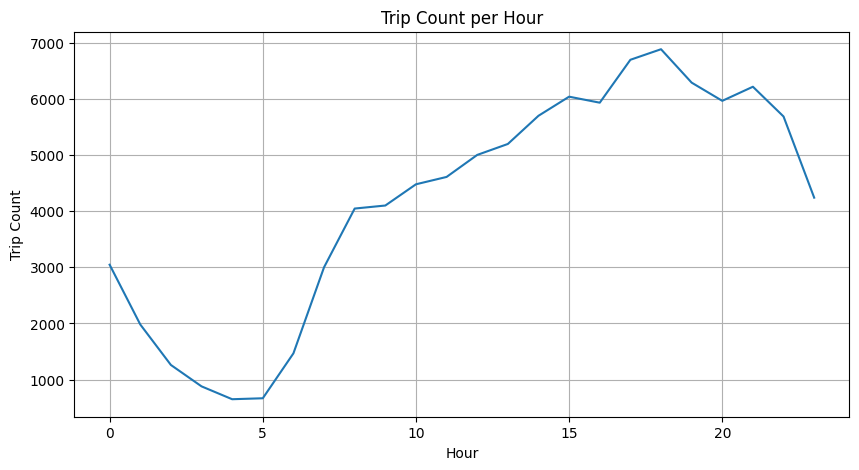

In [11]:
trip_per_hour = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="trip_count")
)

plt.figure(figsize=(10,5))
plt.plot(
    trip_per_hour["pickup_hour"],
    trip_per_hour["trip_count"]
)

plt.xlabel("Hour")
plt.ylabel("Trip Count")
plt.title("Trip Count per Hour")
plt.grid(True)

plt.show()

In [12]:
trip_per_hour = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="trip_count")
      .sort_values("pickup_hour")
)

trip_per_hour

,pickup_hour,trip_count
0,0,3045
1,1,1981
2,2,1260
3,3,879
4,4,650
5,5,667
6,6,1467
7,7,3000
8,8,4045
9,9,4099


In [6]:
revenue_per_hour = (
    df.groupby("pickup_hour")["total_amount"]
      .mean()
      .reset_index()
)

revenue_per_hour

,pickup_hour,total_amount
0,0,29.115923
1,1,26.303814
2,2,25.797267
3,3,25.766068
4,4,29.107892
5,5,36.466725
6,6,35.990925
7,7,31.066556
8,8,28.563862
9,9,28.010997


In [13]:
# pengaruh cuaca 

rain_analysis = (
    df.groupby("is_raining")
      .size()
      .reset_index(name="trip_count")
)

rain_analysis

,is_raining,trip_count
0,False,56545
1,True,43455


In [14]:
# revenue per hour berdasarkan cuaca

revenue_rain = (
    df.groupby("is_raining")["total_amount"]
      .mean()
      .reset_index(name="avg_revenue")
)

revenue_rain

,is_raining,avg_revenue
0,False,27.590828
1,True,27.116637


In [16]:
print(df.columns.tolist())

['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_location_id', 'dropoff_location_id', 'fare_amount', 'tip_amount', 'total_amount', 'trip_duration_min', 'location_id', 'pickup_borough', 'pickup_zone', 'pickup_hour', 'day_name', 'tip_percentage', 'temperature_2m_max', 'precipitation_sum', 'weathercode', 'is_raining']


mapping kategori cuaca 

In [17]:
df["weather_label"] = df["weathercode"].map({
    0: "Clear",
    1: "Mainly Clear",
    2: "Partly Cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Fog",
    51: "Light Drizzle",
    53: "Drizzle",
    55: "Heavy Drizzle",
    61: "Light Rain",
    63: "Rain",
    65: "Heavy Rain",
    71: "Light Snow",
    73: "Snow",
    75: "Heavy Snow"
})

In [19]:
weather_category_analysis = (
    df.groupby("weather_label")["total_amount"]
      .mean()
      .reset_index(name="avg_revenue")
      .sort_values("avg_revenue", ascending=False)
)

weather_category_analysis

,weather_label,avg_revenue
9,Partly Cloudy,29.881587
1,Heavy Drizzle,29.472660
2,Heavy Rain,29.320268
7,Mainly Clear,28.798174
10,Rain,27.701749
4,Light Drizzle,27.597920
8,Overcast,27.457954
5,Light Rain,27.413455
6,Light Snow,26.905702
0,Drizzle,26.030094


In [20]:
weather_trip_analysis = (
    df.groupby("weather_label")
      .size()
      .reset_index(name="trip_count")
      .sort_values("trip_count", ascending=False)
)

weather_trip_analysis

,weather_label,trip_count
8,Overcast,52238
10,Rain,9480
4,Light Drizzle,7809
11,Snow,5786
6,Light Snow,4751
5,Light Rain,4443
0,Drizzle,3738
3,Heavy Snow,3334
7,Mainly Clear,2700
2,Heavy Rain,2422


In [21]:
revenue_per_hour = (
    df.groupby("pickup_hour")["total_amount"]
      .mean()
      .reset_index(name="avg_revenue")
)

revenue_per_hour

,pickup_hour,avg_revenue
0,0,27.298085
1,1,25.263286
2,2,24.499984
3,3,25.364858
4,4,30.053662
5,5,35.102804
6,6,30.608194
7,7,27.444217
8,8,25.707117
9,9,25.763367


In [22]:
tip_per_hour = (
    df.groupby("pickup_hour")["tip_percentage"]
      .mean()
      .reset_index(name="avg_tip_percentage")
)

tip_per_hour

,pickup_hour,avg_tip_percentage
0,0,15.795987
1,1,15.306951
2,2,15.192095
3,3,14.642366
4,4,12.035631
5,5,13.510390
6,6,14.626183
7,7,15.637160
8,8,17.017068
9,9,18.498878
